<a href="https://colab.research.google.com/github/sankalp120/machinelearning/blob/main/mllab_17_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
# Create dataset
data = {
    "Outlook": ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast",
                "Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"],
    "Temp": ["Hot","Hot","Hot","Mild","Cool","Cool","Cool",
             "Mild","Cool","Mild","Mild","Mild","Hot","Mild"],
    "Humidity": ["High","High","High","High","Normal","Normal","Normal",
                 "High","Normal","Normal","Normal","High","Normal","High"],
    "Wind": ["Weak","Strong","Weak","Weak","Weak","Strong","Strong",
             "Weak","Weak","Weak","Strong","Strong","Weak","Strong"],
    "PlayTennis": ["No","No","Yes","Yes","Yes","No","Yes",
                   "No","Yes","Yes","Yes","Yes","Yes","No"]
}

df = pd.DataFrame(data)

In [2]:
# Encode categorical variables
label_encoders = {}
for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [4]:
# Features and target
X = df.drop("PlayTennis", axis=1)
y = df["PlayTennis"]

In [5]:
# Train ID3-like Decision Tree (entropy criterion)
model = DecisionTreeClassifier(criterion="entropy", random_state=42)
model.fit(X, y)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [6]:
# Predict example
sample = pd.DataFrame({
    "Outlook": [label_encoders["Outlook"].transform(["Sunny"])[0]],
    "Temp": [label_encoders["Temp"].transform(["Cool"])[0]],
    "Humidity": [label_encoders["Humidity"].transform(["High"])[0]],
    "Wind": [label_encoders["Wind"].transform(["Strong"])[0]]
})

In [7]:
prediction = model.predict(sample)
print("Prediction (PlayTennis):",
      label_encoders["PlayTennis"].inverse_transform(prediction)[0])

Prediction (PlayTennis): No


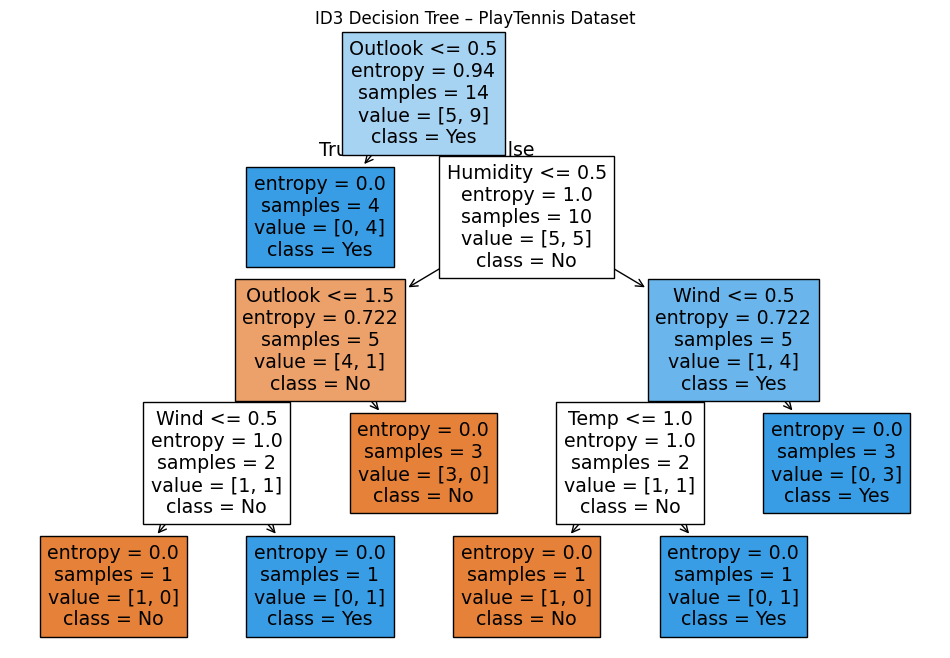

In [8]:
# Plot tree
plt.figure(figsize=(12,8))
plot_tree(model,
          feature_names=X.columns,
          class_names=label_encoders["PlayTennis"].classes_,
          filled=True)
plt.title("ID3 Decision Tree – PlayTennis Dataset")
plt.show()